# Interactive demo — close evaluation for a chain of **arbitrary star-shaped** scatterers

This is `Nspheres_interactive.ipynb` generalised from spheres to arbitrary
smooth star-shaped bodies $y = C_i + Q_i\,\rho_i(\cos\theta)\,\hat r$: a plane
wave $e^{ikz}$ hits a chain of bodies stacked along the $z$-axis, each with its
own **shape**, **tilt** and **gap** to its neighbour.  The field is represented
by double-layer potentials, $u=e^{ikz}+\sum_i D_i[u_i]$, and the Galerkin block
system for the traces is solved with the off-diagonal coupling blocks assembled
by the close-evaluation quadrature of Carvalho, Khatri & Kim — the integration
grid on the source body is rotated so its pole sits at the point closest to the
target, and an exactly-integrable plane wave matching the density there is
subtracted and restored analytically (Khatri, Kim, Cortez & Carvalho,
*J. Comput. Phys.* 2020; Carvalho, *Math. Comput. Appl.* 2021).

**What changes when the spheres go away.**  Three things, and they are the
whole content of this notebook:

1. *No closed-form ground truth.*  The sphere demo could plot a true error map
   because $D[\tilde P_n](x) = ik^2a^2 j_n'(ka)h_n^{(1)}(k|x-C|)\tilde
   P_n(\cos\gamma)$ gives the layer potential in closed form at any distance.
   No such identity exists for a peanut.  The reference here is instead the
   **same** subtraction quadrature at a much higher order $N_q^{ref}$, and the
   notebook *reports its own self-convergence* so you can see how much of the
   plotted error is reference noise.  This is the honest replacement, and it is
   also the situation every real application is in.
2. *Placement is not arithmetic.*  For spheres a gap is $z_2-z_1-a_1-a_2$.  For
   two tilted peanuts the minimum surface separation has no formula, so
   `place_chain` **bisects** the axial offset until the numerically measured
   surface gap hits the requested value.
3. *Cost.*  The sphere evaluator has a closed form and an optional numba
   kernel; here every close evaluation rebuilds a rotated $O(N_q\times 2N_q)$
   grid and its spherical harmonics per target.  A recompute takes on the order
   of a minute rather than a few seconds, and the error maps are therefore
   computed on a subsampled grid, restricted to the near-surface band where all
   the action is.

Everything else — the formulation, the block system, the plots — is the same
demonstration: naive product-Gauss quadrature grows an $O(1)$ error halo
hugging each surface, and the subtraction quadrature removes it at the same
quadrature size.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

import starshape_bie as ss
import starmulti_bie as sm
from starshape_bie import _geometry

np.set_printoptions(precision=4, suppress=True)


def rot(axis, ang):
    a = np.asarray(axis, float); a = a / np.linalg.norm(a)
    K = np.array([[0, -a[2], a[1]], [a[2], 0, -a[0]], [-a[1], a[0], 0]])
    return np.eye(3) + np.sin(ang) * K + (1 - np.cos(ang)) * (K @ K)


# The single-body operator (1/2 M - K) depends only on (shape, Nb, k, N_q) --
# it is frame invariant, as validated in nonspherical_scattering.ipynb -- and
# costs a Python loop over every collocation point, which dominates a solve.
# Memoise it so that dragging a gap or a tilt slider does not re-assemble it.
# (starmulti_bie imports self_operator into its own namespace, so this is the
# name its assemble() actually calls.)
_SELF_CACHE = {}
_self_operator_raw = ss.self_operator


def _self_operator_cached(shape, Nb, k, quad_order=None, return_parts=False):
    key = (id(shape), Nb, float(k), quad_order, return_parts)
    if key not in _SELF_CACHE:
        _SELF_CACHE[key] = _self_operator_raw(shape, Nb, k,
                                              quad_order=quad_order,
                                              return_parts=return_parts)
    return _SELF_CACHE[key]


sm.self_operator = _self_operator_cached
print("ready")

ready


## The shape catalogue

Any `starshape_bie.Shape` works — the solver only ever asks a shape for
$\rho(\mu)$ and $\mathrm{d}\rho/\mathrm{d}\mu$.  Besides the sphere, peanut and
mushroom cap already in the module, this notebook uses the one-parameter family

$$\rho(\mu) = a\,\bigl(1+\varepsilon P_n(\mu)\bigr),\qquad \mu=\cos\theta,$$

(`starshape_bie.legendre_bump`) with $P_n$ the Legendre polynomial: $\rho$ is a
polynomial in $\mu$, so the surface is smooth including at the poles, and
$|P_n|\le 1$ keeps $\rho>0$ for $|\varepsilon|<1$.  $n=1$ is a pear, $n=2$ a
waisted body, larger $n$ gives $n$ lobes stacked along the axis.

Shape *instances* are memoised by name so that repeated widget presses reuse
the same object — which is what makes the `self_operator` cache above hit.

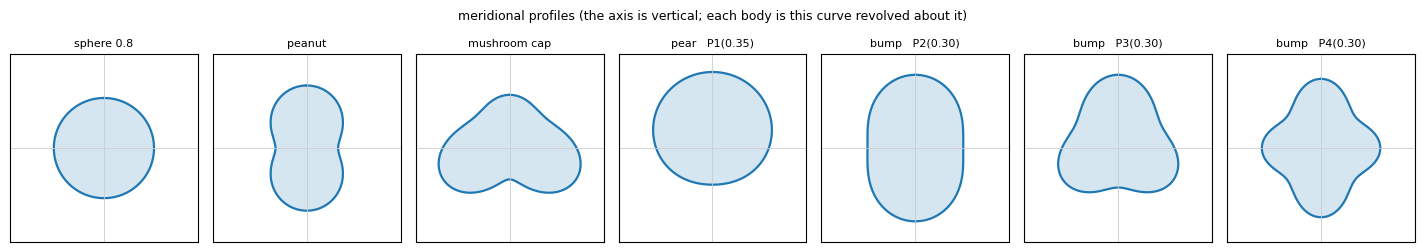

In [2]:
_SHAPE_FACTORIES = {
    'sphere 0.8':      lambda: ss.sphere(0.8),
    'peanut':          lambda: ss.peanut(),
    'mushroom cap':    lambda: ss.mushroom_cap(),
    'pear   P1(0.35)': lambda: ss.legendre_bump(0.90, 0.35, 1),
    'bump   P2(0.30)': lambda: ss.legendre_bump(0.90, 0.30, 2),
    'bump   P3(0.30)': lambda: ss.legendre_bump(0.90, 0.30, 3),
    'bump   P4(0.30)': lambda: ss.legendre_bump(0.85, 0.30, 4),
}
SHAPE_NAMES = list(_SHAPE_FACTORIES)
_SHAPE_CACHE = {}


def get_shape(name):
    if name not in _SHAPE_CACHE:
        _SHAPE_CACHE[name] = _SHAPE_FACTORIES[name]()
    return _SHAPE_CACHE[name]


fig, axs = plt.subplots(1, len(SHAPE_NAMES), figsize=(2.05 * len(SHAPE_NAMES), 2.6),
                        subplot_kw=dict(aspect='equal'))
th = np.linspace(0, 2 * np.pi, 401)
for ax, nm in zip(axs, SHAPE_NAMES):
    sh = get_shape(nm)
    r = sh.rho(np.cos(th))
    ax.plot(r * np.sin(th), r * np.cos(th), lw=1.6)
    ax.fill(r * np.sin(th), r * np.cos(th), alpha=0.18)
    ax.axhline(0, color='0.8', lw=0.6); ax.axvline(0, color='0.8', lw=0.6)
    ax.set_title(nm, fontsize=8); ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('meridional profiles (the axis is vertical; each body is this '
             'curve revolved about it)', fontsize=9)
fig.tight_layout(); plt.show()

### Validation — the new shapes really are solved correctly

Before trusting any error map, check the geometry and both layer potentials on
these shapes with the one test that has an exact answer: put a point source
$\Phi_p(x)=e^{ik|x-p|}/4\pi|x-p|$ *inside* a body, so $u=\Phi_p$ is a radiating
Helmholtz solution in the exterior and the Green representation

$$u(x) = D[u|_S](x) - S[\partial_\nu u|_S](x),\qquad x\ \text{exterior},$$

must reproduce it.  This exercises $\rho$, $\mathrm{d}\rho/\mathrm{d}\mu$, the
outward normal, the area density $W=\rho\sqrt{\rho^2+\rho_\theta^2}$, the
rotated grid and the close evaluation together — a sign or a Jacobian wrong
anywhere and the identity fails.  The residual grows gently with the lobe count
because the trace $\Phi_p|_S$ needs more $Y_n^m$ to resolve, not because the
quadrature degrades.

In [3]:
from starshape_bie import _collocation
from essentials_bie import ComputeSphericalHarmonics

def green_rep_check(shape, Nb=14, q=28, kk=2.0, p=np.array([0.03, -0.02, 0.05])):
    """max relative error of the exterior Green representation for an interior
    point source (exact answer: the source field itself)."""
    body = (shape, np.zeros(3), np.eye(3))
    assert sm.interior_mask([body], p[None])[0], "source is not inside the body"

    def u_ex(X):
        r = np.linalg.norm(np.atleast_2d(X) - p, axis=1)
        return np.exp(1j * kk * r) / (4 * np.pi * r)

    def gradPhi(X):
        d = np.atleast_2d(X) - p
        r = np.linalg.norm(d, axis=-1, keepdims=True)
        return np.exp(1j * kk * r) / (4 * np.pi * r) * (1j * kk - 1 / r) * d / r

    N, M, TH, PH, W_GL, S, T, ws = _collocation(q)
    Yc, _, _ = ComputeSphericalHarmonics(Nb, TH, PH)
    yl, _, _ = _geometry(shape, TH, PH)
    c = (Yc.conj().T * W_GL) @ u_ex(yl)          # trace coefficients (pointwise)

    quad = ss.StarQuadrature(q)
    X = np.array([[2.5, 0.3, -0.4], [0.0, 2.2, 0.8], [-1.8, -0.9, 1.1]])
    D = sm.dlp_bodies(body, Nb, kk, X, quad, band=0.3) @ c
    Sl = ss.slp_density_targets(shape, kk, X,
                                lambda y, nu: np.sum(gradPhi(y) * nu, axis=1),
                                quad, method='rotated')
    return float(np.max(np.abs((D - Sl) - u_ex(X)) / np.abs(u_ex(X))))


for nm in SHAPE_NAMES:
    e = green_rep_check(get_shape(nm))
    print(f"  {nm:16s}: Green representation, max rel err = {e:.2e}")
    assert e < 1e-6, nm
print("all shapes pass the exterior Green representation")

  sphere 0.8      : Green representation, max rel err = 2.27e-15
  peanut          : Green representation, max rel err = 5.16e-09


  mushroom cap    : Green representation, max rel err = 7.53e-08
  pear   P1(0.35) : Green representation, max rel err = 2.43e-15


  bump   P2(0.30) : Green representation, max rel err = 5.89e-12
  bump   P3(0.30) : Green representation, max rel err = 1.52e-09


  bump   P4(0.30) : Green representation, max rel err = 5.45e-08
all shapes pass the exterior Green representation


## Geometry — stacking bodies with a *measured* gap

`place_chain` puts body $0$ at the origin and slides each next body up the
$z$-axis.  The starting offset comes from the bounding slabs
($z^{max}_i - z^{min}_{i+1}$), which for tilted non-convex bodies gives a gap
that is only a **lower** bound — the extreme points of two bodies need not sit
above one another.  A bisection on the offset then drives the numerically
measured minimum surface separation (a dense sampling of one surface against
`starmulti_bie.surface_distance` of the other) onto the requested value, so the
"gap = 0.02" on the slider is the real distance between the two surfaces.

In [4]:
def to_local(C, Q, X):
    return (np.asarray(X, float) - np.asarray(C, float)) @ np.asarray(Q, float)


def body_points(shape, Q, nth=121, nph=122):
    """Dense sampling of a body's surface in its placed orientation (no shift)."""
    th = np.linspace(0, np.pi, nth); ph = np.linspace(-np.pi, np.pi, nph)
    TH, PH = np.meshgrid(th, ph, indexing='ij')
    yl, _, _ = _geometry(shape, TH.ravel(), PH.ravel())
    return yl @ np.asarray(Q).T


def surface_dists(pts, bodies):
    """(len(pts), nbodies) distance from each point to each body's surface."""
    return np.column_stack([sm.surface_distance(sh, to_local(C, Q, pts))
                            for sh, C, Q in bodies])


def gap_between(bi, bj):
    """Measured minimum surface-to-surface distance between two bodies."""
    shi, Ci, Qi = bi
    shj, Cj, Qj = bj
    Xg = Ci + body_points(shi, Qi)
    return float(sm.surface_distance(shj, to_local(Cj, Qj, Xg)).min())


def place_chain(shapes, Qs, gaps, tol=1e-5):
    """Stack bodies along +z so each consecutive MEASURED surface gap equals
    the requested value.  Returns (bodies, zs, measured_gaps, z_extents)."""
    ext = []
    for sh, Q in zip(shapes, Qs):
        z = body_points(sh, Q)[:, 2]
        ext.append((float(z.min()), float(z.max())))
    bodies = [(shapes[0], np.zeros(3), Qs[0])]
    zs = [0.0]
    for i, g in enumerate(gaps):
        mk = lambda z: (shapes[i + 1], np.array([0.0, 0.0, z]), Qs[i + 1])
        z_slab = zs[-1] + ext[i][1] - ext[i + 1][0]      # slab contact: gap >= 0
        # bracket [a, b] with gap(a) < g <= gap(b), then bisect
        b = z_slab
        while gap_between(bodies[-1], mk(b)) < g:
            b += max(g, 0.25)
        a = b
        step = max(g, 0.25)
        while gap_between(bodies[-1], mk(a)) >= g:
            a -= step; step *= 1.6
        for _ in range(80):
            m = 0.5 * (a + b)
            if gap_between(bodies[-1], mk(m)) < g:
                a = m
            else:
                b = m
            if b - a < tol:
                break
        bodies.append(mk(b)); zs.append(b)
    meas = [gap_between(bodies[i], bodies[i + 1]) for i in range(len(bodies) - 1)]
    return bodies, zs, meas, ext


def xz_outline(ax, Xg, Zg, inside, color='k', lw=1.2):
    """Outline of the bodies' section with the plotting plane, taken as the
    0.5-level of the interior indicator on the plotting grid.

    (Contouring the *surface* points projected into the plane does not work:
    the projection folds, so a triangulation of it is degenerate and the level
    set degenerates into a tangle filling the silhouette.)"""
    ax.contour(Xg, Zg, inside.astype(float), levels=[0.5],
               colors=color, linewidths=lw)

## Field evaluation

`scattered` evaluates $\sum_i D_i[u_i](x)$ with a **single** quadrature method
everywhere (that is what the error maps need), and `scattered_hybrid` uses the
subtraction quadrature within a band of each surface and the cheap naive grid
elsewhere (that is what the field maps use — beyond $\approx 0.3$ of a surface
the two agree to the quadrature floor).  Both return `NaN` inside the bodies.

The three single-method modes are expressed through `starmulti_bie.dlp_bodies`'
own switches: `band=0` sends every target to `far_method`, and `band=inf`
sends every target to the subtraction branch.

In [5]:
# 'naive'/'rotated'/'subtract' as one method everywhere, via dlp_bodies switches
_MODE = {'naive':    (0.0, 'naive'),
         'rotated':  (0.0, 'rotated'),
         'subtract': (np.inf, 'rotated')}


def scattered(pts, bodies, coeffs, Nb, k, quad, method):
    """sum_i D_i[u_i](x) with one quadrature method everywhere; NaN inside."""
    pts = np.atleast_2d(pts)
    band, far = _MODE[method]
    u = np.full(len(pts), np.nan, dtype=complex)
    idx = np.where(~sm.interior_mask(bodies, pts))[0]
    if len(idx) == 0:
        return u
    acc = np.zeros(len(idx), dtype=complex)
    for (sh, C, Q), c in zip(bodies, coeffs):
        acc += sm.dlp_bodies((sh, C, Q), Nb, k, pts[idx], quad,
                             band=band, far_method=far) @ c
    u[idx] = acc
    return u


def scattered_hybrid(pts, bodies, coeffs, Nb, k, quad, band=0.35):
    """Subtraction within `band` of each surface, naive elsewhere; NaN inside."""
    pts = np.atleast_2d(pts)
    u = np.full(len(pts), np.nan, dtype=complex)
    idx = np.where(~sm.interior_mask(bodies, pts))[0]
    if len(idx) == 0:
        return u
    acc = np.zeros(len(idx), dtype=complex)
    for (sh, C, Q), c in zip(bodies, coeffs):
        acc += sm.dlp_bodies((sh, C, Q), Nb, k, pts[idx], quad,
                             band=band, far_method='naive') @ c
    u[idx] = acc
    return u

## The demo function

`recompute` places the chain, solves the coupled system, and draws three rows:

1. **Total field** $\operatorname{Re}u$ and $|u|$ in the $x$–$z$ plane, which
   contains every center (hybrid evaluation).
2. **The selling plot** — $\log_{10}$ absolute error of the scattered field
   against the refined reference, naive on the left, CKK + subtraction on the
   right, same color scale.  Both use the same solved coefficients; only the
   evaluation quadrature differs.  Computed on a grid subsampled by
   `err_stride` and restricted to points within `err_reach` of a surface, which
   is where naive quadrature fails and where the map is worth its cost;
   everything outside is left blank.
3. $|u|$ **on the $z$-axis** — the full line and a zoom into each gap —
   computed three ways.  This row is cheap (a few hundred points), so it is
   the quantitative statement: the naive curve breaks away from the reference
   as the axis approaches each surface, the subtraction curve tracks it.

Before the maps, the reference's **own** convergence is measured by comparing
$N_q^{ref}$ against $N_q^{ref}+8$ on a sample of near-surface points.  Read the
error maps against that number: anything at or below it is reference noise.

In [6]:
def recompute(shape_names=('peanut', 'mushroom cap', 'bump   P3(0.30)'),
              tilts_deg=(0.0, 35.0, -25.0), gaps=(0.05, 0.15),
              k=2.0, Nbasis=10, Nq=16, Nq_ref=32,
              nx=100, nz_cap=200, err_stride=2, err_reach=0.6, pad=1.4):
    """Solve the chain and draw the three plot rows."""
    if min(gaps) <= 0:
        print(f"gaps must be positive (got {gaps})"); return
    t_all = time.time()

    # ---- geometry: measured gaps by bisection ----
    t0 = time.time()
    shapes = [get_shape(n) for n in shape_names]
    axes_t = [[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [1.0, 1.0, 0.0]]
    Qs = [np.eye(3) if abs(a) < 1e-12 else rot(axes_t[i % 3], np.deg2rad(a))
          for i, a in enumerate(tilts_deg)]
    bodies, zs, meas, ext = place_chain(shapes, Qs, gaps)
    t_geo = time.time() - t0
    print("shapes  : " + ", ".join(shape_names))
    print(f"tilts   : {np.array(tilts_deg)} deg")
    print(f"centers : z = {np.round(zs, 4)}")
    print(f"gaps    : requested {np.array(gaps)}  ->  measured "
          f"{np.round(meas, 6)}   ({t_geo:.1f} s of bisection)")
    print(f"k={k:g}, Nbasis={Nbasis} ({len(bodies) * Nbasis**2} unknowns), "
          f"Nq={Nq}, Nq_ref={Nq_ref}")

    quad = ss.StarQuadrature(Nq)
    quad_ref = ss.StarQuadrature(Nq_ref)
    quad_chk = ss.StarQuadrature(Nq_ref + 8)

    # ---- solve ----
    t0 = time.time()
    coeffs = sm.solve(bodies, Nbasis, k, quad_order=Nq)
    t_solve = time.time() - t0
    print(f"block system solved in {t_solve:.1f} s")

    # ---- plot window ----
    amax = max(np.abs(body_points(sh, Q)[:, 0]).max() for sh, Q in zip(shapes, Qs))
    xlim = (-(amax + pad), amax + pad)
    zlim = (zs[0] + ext[0][0] - pad, zs[-1] + ext[-1][1] + pad)
    nz = min(nz_cap, max(60, int(round(nx * (zlim[1] - zlim[0])
                                       / (xlim[1] - xlim[0])))))
    Xg, Zg = np.meshgrid(np.linspace(*xlim, nx), np.linspace(*zlim, nz))
    pts = np.column_stack([Xg.ravel(), np.zeros(Xg.size), Zg.ravel()])

    # ---- row 1: total field ----
    t0 = time.time()
    U = (np.exp(1j * k * pts[:, 2])
         + scattered_hybrid(pts, bodies, coeffs, Nbasis, k, quad)).reshape(nz, nx)
    t_field = time.time() - t0
    print(f"total field on {nx} x {nz} grid in {t_field:.1f} s")

    # ---- reference self-convergence on a sample of near points ----
    t0 = time.time()
    de = surface_dists(pts, bodies).min(axis=1)
    near_all = np.where((~sm.interior_mask(bodies, pts)) & (de < 0.2))[0]
    samp = near_all[np.linspace(0, len(near_all) - 1, min(60, len(near_all))).astype(int)] \
        if len(near_all) else np.array([], dtype=int)
    if len(samp):
        a1 = scattered(pts[samp], bodies, coeffs, Nbasis, k, quad_ref, 'subtract')
        a2 = scattered(pts[samp], bodies, coeffs, Nbasis, k, quad_chk, 'subtract')
        ref_noise = float(np.nanmax(np.abs(a1 - a2)))
    else:
        ref_noise = np.nan
    t_chk = time.time() - t0
    print(f"reference self-convergence |u(Nq={Nq_ref}) - u(Nq={Nq_ref + 8})| on "
          f"{len(samp)} points within 0.2 of a surface: {ref_noise:.2e} "
          f"({t_chk:.1f} s)")

    # ---- row 2: error maps on a subsampled near-surface band ----
    t0 = time.time()
    Xe, Ze = Xg[::err_stride, ::err_stride], Zg[::err_stride, ::err_stride]
    pe = np.column_stack([Xe.ravel(), np.zeros(Xe.size), Ze.ravel()])
    de = surface_dists(pe, bodies).min(axis=1)
    sel = (~sm.interior_mask(bodies, pe)) & (de < err_reach)
    P = pe[sel]
    u_ref = scattered(P, bodies, coeffs, Nbasis, k, quad_ref, 'subtract')
    e_nai = np.full(Xe.shape, np.nan)
    e_sub = np.full(Xe.shape, np.nan)
    e_nai.ravel()[sel] = np.abs(
        scattered(P, bodies, coeffs, Nbasis, k, quad, 'naive') - u_ref)
    e_sub.ravel()[sel] = np.abs(
        scattered(P, bodies, coeffs, Nbasis, k, quad, 'subtract') - u_ref)
    t_err = time.time() - t0
    print(f"error maps on {Xe.shape[1]} x {Xe.shape[0]} subsampled grid, "
          f"{sel.sum()} points within {err_reach:g} of a surface, in {t_err:.1f} s")
    max_nai = np.nanmax(e_nai); max_sub = np.nanmax(e_sub)
    print(f"max |error| in that band: naive {max_nai:.1e}, "
          f"subtraction {max_sub:.1e}  (reference noise {ref_noise:.1e})")

    # ---- row 3: |u| on the z-axis, three ways ----
    t0 = time.time()
    zline = np.linspace(zlim[0], zlim[1], 400)
    pl = np.column_stack([np.zeros((len(zline), 2)), zline])
    meth = ('naive', 'subtract')
    lines = {m: np.abs(np.exp(1j * k * zline)
                       + scattered(pl, bodies, coeffs, Nbasis, k, quad, m))
             for m in meth}
    lines['reference'] = np.abs(np.exp(1j * k * zline)
                                + scattered(pl, bodies, coeffs, Nbasis, k,
                                            quad_ref, 'subtract'))
    # the z-axis intervals actually inside / between bodies: a tilted body is
    # not symmetric about the z-axis, so these are measured, not derived from
    # the bounding slabs
    zfine = np.linspace(zlim[0], zlim[1], 4001)
    ins = sm.interior_mask(bodies, np.column_stack(
        [np.zeros((len(zfine), 2)), zfine]))
    runs, i0 = [], None
    for i, v in enumerate(ins):
        if v and i0 is None:
            i0 = i
        elif not v and i0 is not None:
            runs.append((zfine[i0], zfine[i - 1])); i0 = None
    if i0 is not None:
        runs.append((zfine[i0], zfine[-1]))
    gapz = [(runs[i][1], runs[i + 1][0]) for i in range(len(runs) - 1)]
    gapdata = []
    for zlo, zhi in gapz:
        zgz = np.linspace(zlo, zhi, 90)
        p = np.column_stack([np.zeros((len(zgz), 2)), zgz])
        d = {m: np.abs(np.exp(1j * k * zgz)
                       + scattered(p, bodies, coeffs, Nbasis, k, quad, m))
             for m in meth}
        d['reference'] = np.abs(np.exp(1j * k * zgz)
                                + scattered(p, bodies, coeffs, Nbasis, k,
                                            quad_ref, 'subtract'))
        gapdata.append((zgz, d))
    t_line = time.time() - t0
    print(f"axis lines ({len(zline)} + {len(gapz)} x 90 points, three ways) "
          f"in {t_line:.1f} s")

    # ================= figure =================
    ng = len(gapz)
    fig = plt.figure(figsize=(11.5, 14.5))
    gs = fig.add_gridspec(3, 2 * (ng + 1), height_ratios=[1.2, 1.2, 0.55],
                          hspace=0.34, wspace=0.5)

    insideG = sm.interior_mask(bodies, pts).reshape(nz, nx)

    def frame(ax):
        xz_outline(ax, Xg, Zg, insideG)
        ax.set_aspect('equal'); ax.set_xlabel('$x$'); ax.set_ylabel('$z$')
        ax.set_xlim(xlim); ax.set_ylim(zlim)

    ncol = 2 * (ng + 1)
    for j, (F, cmap, ttl, vmin, vmax) in enumerate([
            (np.real(U), 'RdBu_r', 'Re $u$ (total field)', -2.2, 2.2),
            (np.abs(U), 'viridis', '$|u|$ (total field)', 0.0, 2.2)]):
        ax = fig.add_subplot(gs[0, j * ncol // 2:(j + 1) * ncol // 2])
        cm = plt.get_cmap(cmap).copy(); cm.set_bad('white')
        pc = ax.pcolormesh(Xg, Zg, F, cmap=cm, vmin=vmin, vmax=vmax,
                           shading='auto', rasterized=True)
        ax.set_facecolor('white')
        frame(ax); ax.set_title(ttl)
        fig.colorbar(pc, ax=ax, shrink=0.9)

    for j, (err, ttl, mx) in enumerate([
            (e_nai, 'naive product-Gauss quadrature', max_nai),
            (e_sub, 'CKK rotated grid + subtraction', max_sub)]):
        ax = fig.add_subplot(gs[1, j * ncol // 2:(j + 1) * ncol // 2])
        cm = plt.get_cmap('magma').copy(); cm.set_bad('white')
        pc = ax.pcolormesh(Xe, Ze, np.log10(np.maximum(err, 1e-17)), cmap=cm,
                           vmin=-10, vmax=1, shading='nearest', rasterized=True)
        ax.set_facecolor('white')
        frame(ax)
        ax.set_title(f'$\\log_{{10}}$ |scattered-field error| vs $N_q^{{ref}}='
                     f'{Nq_ref}$\n{ttl}')
        ax.text(0.03, 0.02, f'max in band: {mx:.1e}', transform=ax.transAxes,
                fontsize=10, va='bottom',
                bbox=dict(facecolor='w', alpha=0.85, edgecolor='none',
                          boxstyle='round,pad=0.3'))
        fig.colorbar(pc, ax=ax, shrink=0.9)

    def three_lines(ax, zv, curves):
        ax.plot(zv, curves['reference'], color='k', ls=':', lw=2.5,
                label=f'reference ($N_q={Nq_ref}$)')
        ax.plot(zv, curves['naive'], color='#d95f02', ls='--', lw=1.8,
                label='naive quadrature')
        ax.plot(zv, curves['subtract'], color='#1b6ca8', lw=1.8,
                label='CKK + subtraction')
        ax.set_xlabel('$z$ (on the axis)'); ax.set_ylabel('$|u|$')
        ax.grid(alpha=0.3)

    ax = fig.add_subplot(gs[2, 0:2])
    three_lines(ax, zline, lines)
    fin = lines['reference'][np.isfinite(lines['reference'])]
    ax.set_ylim(0, 1.35 * np.max(fin)); ax.set_xlim(zlim)
    for zlo, zhi in runs:
        ax.axvspan(zlo, zhi, color='0.85', zorder=0)
    ax.set_title('$|u|$ on the $z$-axis (gray = inside)', fontsize=9)
    ax.legend(loc='upper left', framealpha=0.9, fontsize=8)

    for jg, ((zlo, zhi), (zgz, curves)) in enumerate(zip(gapz, gapdata)):
        ax = fig.add_subplot(gs[2, 2 * jg + 2:2 * jg + 4])
        three_lines(ax, zgz, curves)
        ax.set_ylabel('')
        allv = np.concatenate([v[np.isfinite(v)] for v in curves.values()])
        lo, hi = allv.min(), allv.max()
        pad2 = 0.15 * (hi - lo + 1e-3)
        ax.set_ylim(max(0.0, lo - pad2), hi + pad2); ax.set_xlim(zlo, zhi)
        lbl = f'{meas[jg]:.3g}' if jg < len(meas) else '?'
        ax.set_title(f'zoom: gap {jg + 1}–{jg + 2} (measured {lbl})',
                     fontsize=9)

    fig.suptitle('Chain of star-shaped sound-hard scatterers, '
                 f'$k={k:g}$, measured gaps $= '
                 + ',\\ '.join(f'{g:.3g}' for g in meas) + '$: '
                 'close evaluation vs naive quadrature', y=0.99, fontsize=12)
    plt.show()
    print(f"total: {time.time() - t_all:.1f} s")

## Static run (default parameters)

A peanut, a tilted mushroom cap and a tilted three-lobed Legendre bump, with
measured surface gaps $0.05$ and $0.15$ — the same function the widget button
calls, run directly so the committed notebook shows all three rows without a
live kernel.

shapes  : peanut, mushroom cap, bump   P3(0.30)
tilts   : [  0.  35. -25.] deg
centers : z = [0.     2.0177 3.7638]
gaps    : requested [0.05 0.15]  ->  measured [0.05 0.15]   (0.7 s of bisection)
k=2, Nbasis=10 (300 unknowns), Nq=16, Nq_ref=32


block system solved in 6.8 s


total field on 100 x 170 grid in 10.1 s


reference self-convergence |u(Nq=32) - u(Nq=40)| on 60 points within 0.2 of a surface: 2.27e-03 (6.8 s)


error maps on 50 x 85 subsampled grid, 978 points within 0.6 of a surface, in 56.2 s
max |error| in that band: naive 5.9e+02, subtraction 1.2e-02  (reference noise 2.3e-03)


axis lines (400 + 2 x 90 points, three ways) in 18.2 s


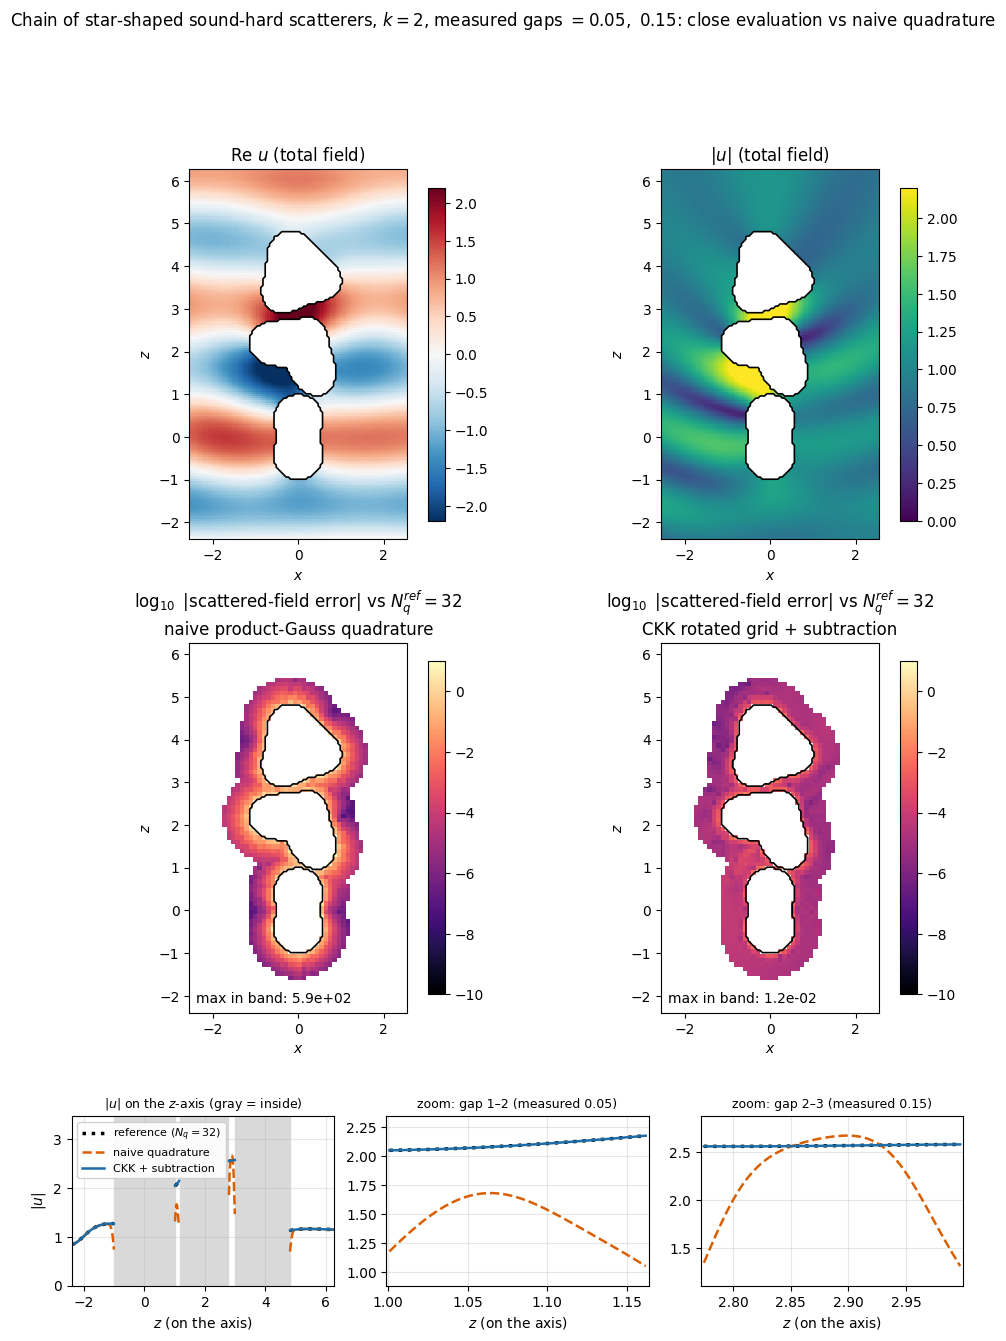

total: 99.1 s
wall time: 99.1 s


In [7]:
t0 = time.time()
recompute()
print(f'wall time: {time.time() - t0:.1f} s')

## Live control panel

Choose a shape and a tilt for each of the three bodies, set the two gaps and
the discretisation, then press **Recompute** (a run takes on the order of a
minute; the button reads *Recomputing…* while it works).  The gap sliders are
logarithmic — push one down to $10^{-2}$ to watch the naive halo swallow the
gap while the subtraction map stays near the reference floor.

Two knobs are worth understanding.  `Nq` is the working quadrature order whose
error is being displayed; `Nq_ref` is the reference order the maps are measured
*against*, and the printed self-convergence number bounds how much of the map
is the reference's own noise.  If the CKK map is not clearly below the naive
one, raise `Nq` — for tight gaps on strongly non-spherical bodies the
subtraction quadrature needs more nodes than a sphere does.

In [8]:
import ipywidgets as w

_dd = lambda v: w.Dropdown(options=SHAPE_NAMES, value=v, layout=w.Layout(width='230px'))
s_sh = [_dd('peanut'), _dd('mushroom cap'), _dd('bump   P3(0.30)')]
s_ti = [w.FloatSlider(value=v, min=-90, max=90, step=5,
                      description=f'tilt {i + 1} (deg)', readout_format='.0f')
        for i, v in enumerate((0.0, 35.0, -25.0))]
s_g12 = w.FloatLogSlider(value=0.05, base=10, min=-2, max=np.log10(2.0),
                         step=0.05, description='gap 1–2', readout_format='.3f')
s_g23 = w.FloatLogSlider(value=0.15, base=10, min=-2, max=np.log10(2.0),
                         step=0.05, description='gap 2–3', readout_format='.3f')
s_k = w.FloatSlider(value=2.0, min=0.5, max=5.0, step=0.1,
                    description='wavenumber $k$')
s_Nb = w.IntSlider(value=10, min=6, max=16, description='$N_{basis}$')
s_Nq = w.IntSlider(value=16, min=10, max=32, step=2, description='$N_q$')
s_Nr = w.IntSlider(value=32, min=20, max=48, step=4, description='$N_q^{ref}$')
s_nx = w.IntSlider(value=100, min=50, max=160, step=10, description='grid $n_x$')
s_st = w.IntSlider(value=2, min=1, max=4, description='err stride')
s_re = w.FloatSlider(value=0.6, min=0.2, max=1.5, step=0.1,
                     description='err reach')
btn = w.Button(description='Recompute', button_style='primary', icon='refresh')
out = w.Output()


def on_click(_):
    btn.description = 'Recomputing…'    # the widget model syncs before the
    btn.disabled = True                 # blocking compute starts
    try:
        with out:
            out.clear_output(wait=True)
            recompute(shape_names=tuple(d.value for d in s_sh),
                      tilts_deg=tuple(s.value for s in s_ti),
                      gaps=(s_g12.value, s_g23.value),
                      k=s_k.value, Nbasis=s_Nb.value, Nq=s_Nq.value,
                      Nq_ref=s_Nr.value, nx=s_nx.value,
                      err_stride=s_st.value, err_reach=s_re.value)
    finally:
        btn.description = 'Recompute'
        btn.disabled = False


btn.on_click(on_click)
panel = w.VBox([
    w.HTML('<b>bodies</b> (stacked along $z$, plane wave travels $+z$)'),
    w.HBox([w.VBox([d, t]) for d, t in zip(s_sh, s_ti)]),
    w.HTML('<b>gaps &amp; physics</b>'),
    w.HBox([s_g12, s_g23, s_k]),
    w.HTML('<b>discretisation &amp; plotting</b>'),
    w.HBox([s_Nb, s_Nq, s_Nr]),
    w.HBox([s_nx, s_st, s_re]),
    btn,
])
display(panel, out)

Output()